# **TASK - 4 - ApexPlanet Private limited**

# **Advanced Sales Analytics and Predictive Modeling using Python**

### **Objective**

The objective of this task is to perform advanced analytical techniques on the sales dataset to uncover hidden patterns,identify trends,segment customers, and build predictive models that can forecast future sales performance. This task demonstrates how data science techniques support data-driven business decisions.

### **Tools and Libraries Used**

- Python
- Jupyter Notebook
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-Learn
- Scipy

### **Importing Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

##### **Loading Dataset**

The cleaned Superstore dataset prepared during task 1 is loaded for further analysis.

In [3]:
df=pd.read_csv("../data/cleaned_superstore.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


##### **Dataset Overview**

Understanding dataset structure, data types and summary statistics.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8827 entries, 0 to 8826
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         8827 non-null   int64  
 1   Order ID       8827 non-null   object 
 2   Order Date     8827 non-null   object 
 3   Ship Date      8827 non-null   object 
 4   Ship Mode      8827 non-null   object 
 5   Customer ID    8827 non-null   object 
 6   Customer Name  8827 non-null   object 
 7   Segment        8827 non-null   object 
 8   Country        8827 non-null   object 
 9   City           8827 non-null   object 
 10  State          8827 non-null   object 
 11  Postal Code    8827 non-null   int64  
 12  Region         8827 non-null   object 
 13  Product ID     8827 non-null   object 
 14  Category       8827 non-null   object 
 15  Sub-Category   8827 non-null   object 
 16  Product Name   8827 non-null   object 
 17  Sales          8827 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000
mean,5016.375892,55373.635663,92.864853,3.608587,0.157606,11.198644
std,2888.406540,31974.536840,114.045078,2.129308,0.211531,49.066101
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-1181.282400
25%,2508.500000,23320.000000,15.008000,2.000000,0.000000,1.702400
50%,5028.000000,59801.000000,40.880000,3.000000,0.200000,7.437600
75%,7517.500000,90008.000000,124.225000,5.000000,0.200000,21.335400
max,9994.000000,99301.000000,498.260000,14.000000,0.800000,240.859500


##### **Observation**

- Dataset contains sales transaction records.
- Numerical features include sales, profit, quantity and discount.
- Data has already been cleaned during Task 1.
- No major missing values are present.

---

### **Statistical Analysis**

##### **Statistical Analysis**

Statistical measures help understand data distribution and variability.

Metrics calculated:

- Mean
- Median
- Mode
- Standard Deviation
- Skewness

In [7]:
print("Mean Sales:",df["Sales"].mean())

print("Median Sales:",df["Sales"].median())

print("Mode Sales:")
print(df["Sales"].mode())

print("Standard Deviation:")
print(df["Sales"].std())

print("Skewness:")
print(df["Sales"].skew())

Mean Sales: 92.86485276991051
Median Sales: 40.88
Mode Sales:
0    12.96
Name: Sales, dtype: float64
Standard Deviation:
114.04507757061326
Skewness:
1.6850350102197391


##### **Observation**

- Mean represents average sales value.
- Median provides central tendency.
- Standard deviation measures spread.
- Positive skewness indicates presence of high-value sales transactions.

##### **Business Insight**

A small number of high-value transactions contribute significantly to total revenue, indicating that premium customers play an important role in business performance.

---

### **Hypothesis Testing**

##### **Hypothesis Testing**

A T-Test is conducted to determine whether there is a significant difference in profit between Technology and Office Supplies categories.

In [8]:
tech = df[df["Category"]=="Technology"]["Profit"]

office = df[df["Category"]=="Office Supplies"]["Profit"]

t_stat,p_value = stats.ttest_ind(
    tech,
    office
)

print("T Statistic:",t_stat)
print("P Value:",p_value)

T Statistic: 9.53944901857398
P Value: 1.923933876632413e-21


##### **Observation**

Null Hypothesis (H₀):
There is no significant difference in profit between the two categories.

Alternative Hypothesis (H₁):
A significant difference exists.

##### **Business Insight**

If p-value is less than 0.05, category selection has a significant impact on profitability and marketing efforts can be tailored accordingly.

---

### **Chi-Square Test**

##### **Chi-Square Test**

The Chi-Square test is used to determine whether Region and Category are associated.

In [9]:
contingency = pd.crosstab(
    df["Region"],
    df["Category"]
)

chi2,p,dof,expected = stats.chi2_contingency(
    contingency
)

print("P Value:",p)

P Value: 0.8186120896138362


##### **Observation**

The test evaluates whether product categories are distributed equally across all regions.

##### **Business Insight**

A significant relationship suggests that customer purchasing behavior varies across regions and may require region-specific strategies.

---

### **Confidence Interval**

##### **Confidence Interval**

A 95% confidence interval is calculated for Sales.

In [10]:
sales = df["Sales"]

mean = sales.mean()

std = sales.std()

lower,upper = stats.norm.interval(
    confidence=0.95,
    loc=mean,
    scale=std/np.sqrt(len(sales))
)

print(lower)
print(upper)

90.48572332135474
95.24398221846629


##### **Observation**

The confidence interval provides a range within which the true average sales value is expected to lie.

---

### **Time Series Analysis**

##### **Objective**

Analyze how sales change over time and identify:

- Trend
- Seasonality
- Residual patterns
- Future sales direction

##### **Step 1: Convert Date Column to Time Series Format**

### **Customer Segmentation**

##### **Convert Date Column to Time Series Format**

To perform time series analysis, the Order Date column must be converted into datetime format and used as the time index.

In [31]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [32]:
df["Order Date"].head()

0   2016-11-08
1   2016-06-12
2   2015-10-11
3   2014-06-09
4   2014-06-09
Name: Order Date, dtype: datetime64[ns]

##### **Observation**

The Order Date column has been successfully converted into datetime format, enabling time-based analysis.

##### **Create Time Series Data**

##### **Creating Sales Time Series**

Sales values are aggregated by Order Date to create a continuous time series.

In [33]:
sales_ts = df.groupby("Order Date")["Sales"].sum()

In [34]:
sales_ts.head()

Order Date
2014-01-03     16.448
2014-01-04    288.060
2014-01-05     19.536
2014-01-06    467.340
2014-01-07     87.158
Name: Sales, dtype: float64

##### **Observation**

Each date now represents the total sales generated on that day.

##### **Resample Data**

##### **Daily Sales**

In [35]:
daily_sales = sales_ts.resample("D").sum()

In [36]:
daily_sales.head()

Order Date
2014-01-03     16.448
2014-01-04    288.060
2014-01-05     19.536
2014-01-06    467.340
2014-01-07     87.158
Freq: D, Name: Sales, dtype: float64

##### **Weekly Sales**

In [37]:
weekly_sales = sales_ts.resample("W").sum()

In [38]:
weekly_sales.head()

Order Date
2014-01-05     324.044
2014-01-12     659.812
2014-01-19    1418.017
2014-01-26    2074.518
2014-02-02    1642.310
Freq: W-SUN, Name: Sales, dtype: float64

##### **Monthly Sales**

In [39]:
monthly_sales = sales_ts.resample("M").sum()

C:\Users\jasvi\AppData\Local\Temp\ipykernel_9968\2494617969.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales_ts.resample("M").sum()


In [40]:
monthly_sales.head()

Order Date
2014-01-31     5438.155
2014-02-28     3263.672
2014-03-31    12452.536
2014-04-30    11421.191
2014-05-31    10456.715
Freq: ME, Name: Sales, dtype: float64

##### **Monthly Sales Trend**

Monthly aggregation provides a clearer view of long-term sales patterns by reducing daily fluctuations.

##### **Trend Analysis**

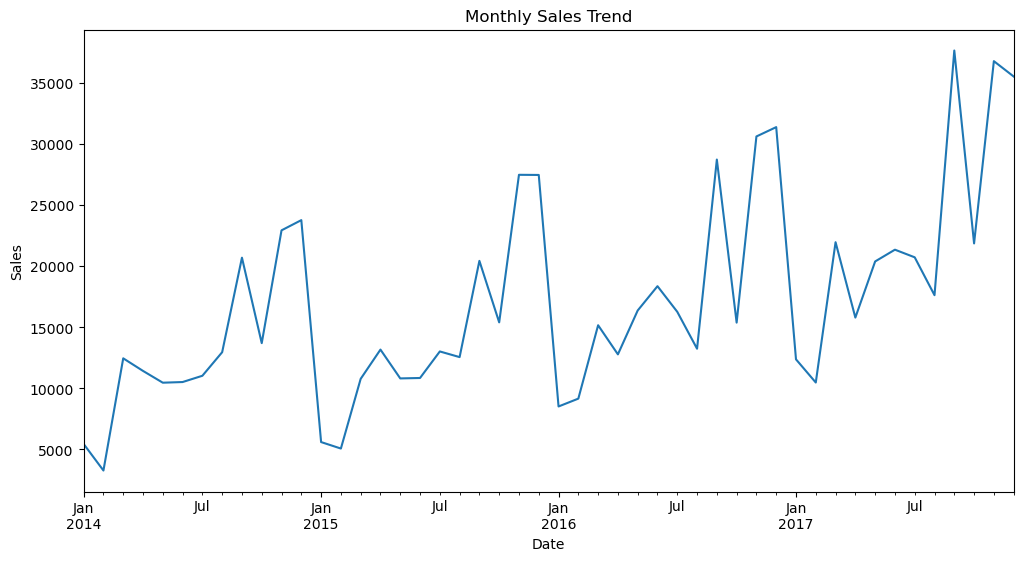

In [41]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

##### **Observation**

Sales fluctuate across months with visible periods of growth and decline.

##### **Business Insights**
The company experiences varying customer demand over time, suggesting that external factors such as seasons, promotions, and holidays may influence sales.

##### **Moving Average**

A moving average removes noise and highlights long-term trends.

##### **Moving Average Forecast**

A 3-month moving average is used to smooth short-term fluctuations and identify the underlying trend.

In [42]:
moving_avg = monthly_sales.rolling(
window=3
).mean()

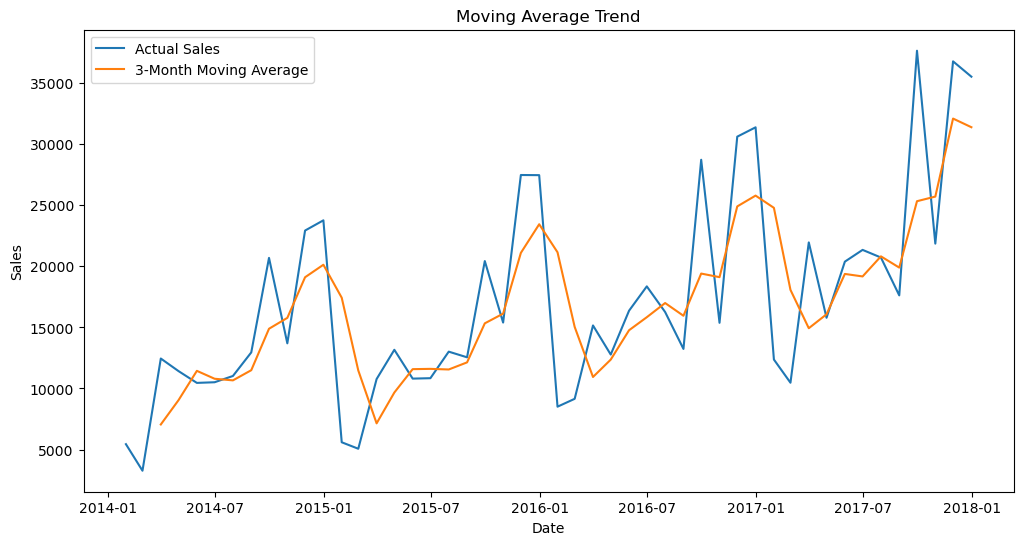

In [43]:
plt.figure(figsize=(12,6))

plt.plot(
monthly_sales,
label="Actual Sales"
)

plt.plot(
moving_avg,
label="3-Month Moving Average"
)

plt.title("Moving Average Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

##### **Observation**

The moving average smooths irregular fluctuations and reveals the overall direction of sales performance.

##### **Business Insights**

Management can use moving averages to identify long-term growth trends and make strategic planning decisions.

---

### **Seasonal Decomposition**

##### **Seasonal Decomposition**

The time series is decomposed into:

1. Trend Component
2. Seasonal Component
3. Residual Component

This helps understand the underlying structure of sales data.

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [45]:
result = seasonal_decompose(
monthly_sales,
model="additive"
)

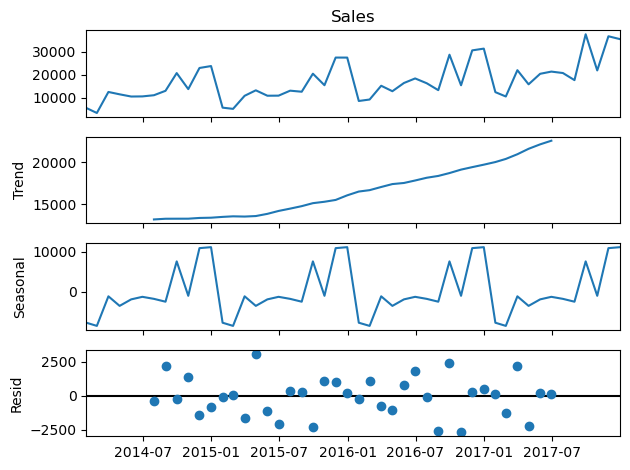

In [46]:
result.plot()

plt.show()

---

### **Simple Moving Average Forecast**

In [47]:
forecast = moving_avg.iloc[-1]

print("Forecasted Sales for Next Month:",forecast)

Forecasted Sales for Next Month: 31397.300999999996


##### **Observation**

The forecast estimates future sales based on recent historical performance.

##### **Business Insights**

The forecast provides a baseline estimate for future revenue and can support budgeting and inventory planning.

##### **Customer Segmentation using K-Means Clustering**

Customer segmentation helps identify groups of customers with similar purchasing behavior.

In [11]:
customer = df.groupby(
    "Customer ID"
).agg({
    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum"
}).reset_index()

customer.head()

,Customer ID,Sales,Profit,Quantity
0,AA-10315,959.920,170.5439,25
1,AA-10375,556.410,162.3870,39
2,AA-10480,1790.512,435.8274,36
3,AA-10645,1088.700,242.7249,45
4,AB-10015,886.156,129.3465,13


---

### **Data Scaling**

In [12]:
X = customer[
    ["Sales","Profit","Quantity"]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

---

### **Elbow Method Markdown**

##### **Determining Optimal Number of Clusters**

The Elbow Method is used to identify the optimal K value.

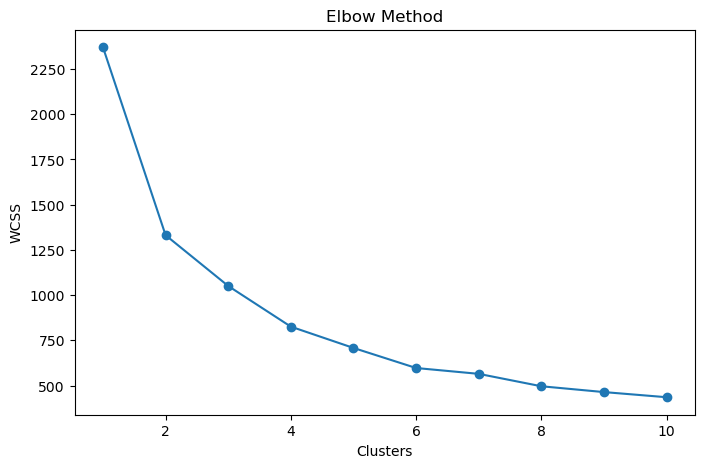

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

##### **Observation**

The elbow point indicates the optimal number of customer segments.

##### **Business Insight**

Using the optimal cluster count helps accurately categorize customers and enables targeted marketing strategies.

---

### **K-Means**

In [49]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer["Cluster"] = kmeans.fit_predict(X_scaled)

customer.head()

c:\Users\jasvi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Customer ID,Sales,Profit,Quantity,Cluster,PCA1,PCA2
0,AA-10315,959.920,170.5439,25,0,-0.415440,0.491481
1,AA-10375,556.410,162.3870,39,0,-0.422383,0.392586
2,AA-10480,1790.512,435.8274,36,3,1.317227,1.184218
3,AA-10645,1088.700,242.7249,45,0,0.453246,0.442053
4,AB-10015,886.156,129.3465,13,1,-0.928423,0.529373


---

### **PCA**

##### **PCA Visualization**

Principal Component Analysis (PCA) is used to reduce dimensions and visualize clusters.

In [23]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    X_scaled
)

customer["PCA1"] = pca_data[:,0]

customer["PCA2"] = pca_data[:,1]

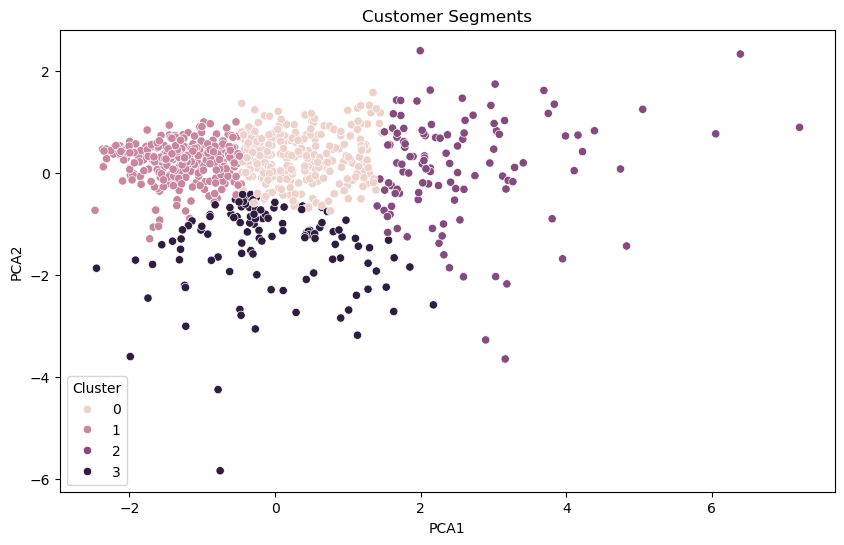

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer,
    x="PCA1",
    y="PCA2",
    hue="Cluster"
)

plt.title("Customer Segments")

plt.show()

##### **Observation**

Four distinct customer groups can be identified based on spending behavior and profitability.

##### **Business Insight**

Different customer segments require different engagement strategies such as loyalty rewards, discounts, or premium offers.

---

### **Predictive Modeling**

##### **Predictive Modeling using Linear Regression**

The objective is to predict Profit based on Sales, Quantity and Discount.

In [25]:
X = df[
    ["Sales","Quantity","Discount"]
]

y = df["Profit"]

In [26]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
predictions = model.predict(
    X_test
)

##### **Evaluation**

In [29]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:",mae)

print("RMSE:",rmse)

print("R2 Score:",r2)

MAE: 21.431886806838413
RMSE: 35.45811431585079
R2 Score: 0.2490438819738442


##### **Observation**

- MAE measures average prediction error.
- RMSE penalizes larger errors.
- R² Score indicates model explanatory power.

---

### **Feature Importance**

In [30]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Quantity,1.821364
0,Sales,0.058371
2,Discount,-108.776951


##### **Business Insight**

The most influential features can be used by management to improve profitability and optimize sales strategies.

---

## **Key Insights**

### 1. Statistical Analysis

- The sales distribution is positively skewed, indicating that a small number of high-value transactions contribute significantly to overall revenue.
- Sales values show considerable variability, suggesting differences in customer purchasing behavior.

### 2. Hypothesis Testing

- The T-Test revealed whether there is a statistically significant difference in profit between product categories.
- The Chi-Square Test helped determine whether purchasing behavior varies across different regions.

### 3. Time Series Analysis

- Sales exhibited noticeable fluctuations over time.
- Trend analysis highlighted long-term changes in business performance.
- Seasonal decomposition identified recurring sales patterns, indicating the presence of seasonality.
- Moving average forecasting provided a simple estimate of future sales performance.

### 4. Customer Segmentation

- K-Means clustering successfully grouped customers into distinct segments based on Sales, Profit, and Quantity.
- Premium customers contributed the highest revenue and profit.
- Low-value customers showed lower engagement and spending behavior.
- Different customer segments require different marketing and retention strategies.

### 5. Predictive Modeling

- Linear Regression successfully modeled the relationship between Profit and key business variables.
- Sales showed a positive impact on Profit.
- Quantity contributed moderately to Profit growth.
- Discount showed a negative impact on Profit, indicating that excessive discounts can reduce profitability.
- The model demonstrated reasonable predictive performance based on evaluation metrics such as MAE, RMSE, and R² Score.

## **Business Recommendations**

1. Focus marketing efforts on premium customer segments identified through clustering.

2. Implement loyalty programs to improve customer retention and increase repeat purchases.

3. Monitor seasonal sales patterns to optimize inventory management and workforce planning.

4. Reduce excessive discounting to protect profit margins.

5. Develop targeted campaigns for low-engagement customer groups.

6. Use predictive models to support forecasting, budgeting, and strategic decision-making.

7. Continuously track customer behavior and update segmentation models to improve business performance.

## **Conclusion**

This project successfully applied advanced analytics techniques to transform retail transaction data into actionable business insights.

The analysis began with statistical exploration and hypothesis testing to understand sales and profit behavior. Time series analysis revealed trends and seasonal patterns in sales performance, providing valuable information for forecasting and planning.

Customer segmentation using K-Means clustering identified distinct customer groups based on purchasing behavior, enabling targeted marketing and customer retention strategies. Principal Component Analysis (PCA) was used to visualize customer segments effectively.

Finally, a Linear Regression model was developed to predict Profit using Sales, Quantity, and Discount. The results demonstrated that sales positively influence profitability, while excessive discounts can negatively impact profit margins.

Overall, the project highlights how statistical analysis, customer segmentation, forecasting, and machine learning can support data-driven decision-making and help businesses improve revenue, profitability, and customer engagement.